# 1D CNN for Human Activity Recognition from Raw Smartphone Sensor Signals

This notebook trains a 1D Convolutional Neural Network on raw smartphone inertial-sensor sequences from the UCI Human Activity Recognition dataset.

Unlike the Random Forest baseline, which uses 561 handcrafted time-domain and frequency-domain features, the CNN receives only raw 9-channel sensor windows of shape `(128, 9)` and learns temporal patterns automatically.

## Experimental protocol

- **Input:** 128 time steps × 9 raw sensor channels
- **Classes:** Walking, Walking Upstairs, Walking Downstairs, Sitting, Standing, Laying
- **Validation split:** subject-aware split using subjects 27–30
- **Test set:** official untouched UCI HAR test partition
- **Model selection:** early stopping based on validation loss
- **Evaluation:** official test accuracy, classification report, confusion matrix, and training curves

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/HAR_1D_CNN_Project")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
CHECKPOINTS_DIR = PROJECT_DIR / "checkpoints"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Load raw signals and labels
# ------------------------------------------------------------
X_train_raw = np.load(PROCESSED_DIR / "X_train_raw.npy")
X_test_raw = np.load(PROCESSED_DIR / "X_test_raw.npy")

y_train = np.load(PROCESSED_DIR / "y_train.npy")
y_test = np.load(PROCESSED_DIR / "y_test.npy")

subjects_train = np.load(PROCESSED_DIR / "subjects_train.npy")
subjects_test = np.load(PROCESSED_DIR / "subjects_test.npy")

ACTIVITY_NAMES = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}

print("Raw train shape:", X_train_raw.shape)
print("Raw test shape: ", X_test_raw.shape)
print("Train labels:   ", y_train.shape)
print("Test labels:    ", y_test.shape)

Raw train shape: (7352, 128, 9)
Raw test shape:  (2947, 128, 9)
Train labels:    (7352,)
Test labels:     (2947,)


In [3]:
# ------------------------------------------------------------
# Subject-aware validation split
# Keep the same validation subjects used for Random Forest.
# ------------------------------------------------------------
VAL_SUBJECTS = np.array([27, 28, 29, 30])

train_mask = ~np.isin(subjects_train, VAL_SUBJECTS)
val_mask = np.isin(subjects_train, VAL_SUBJECTS)

X_train = X_train_raw[train_mask].copy()
X_val = X_train_raw[val_mask].copy()

y_train_split = y_train[train_mask].copy()
y_val = y_train[val_mask].copy()

print("CNN train shape:", X_train.shape)
print("CNN val shape:  ", X_val.shape)
print("CNN test shape: ", X_test_raw.shape)

print("\nTraining subjects:", sorted(np.unique(subjects_train[train_mask]).tolist()))
print("Validation subjects:", sorted(np.unique(subjects_train[val_mask]).tolist()))

assert set(np.unique(subjects_train[train_mask])).isdisjoint(
    set(np.unique(subjects_train[val_mask]))
)

print("\nNo subject leakage: PASSED")

CNN train shape: (5867, 128, 9)
CNN val shape:   (1485, 128, 9)
CNN test shape:  (2947, 128, 9)

Training subjects: [1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26]
Validation subjects: [27, 28, 29, 30]

No subject leakage: PASSED


In [4]:
# ------------------------------------------------------------
# Channel-wise standardization using training data only
# ------------------------------------------------------------
channel_mean = X_train.mean(axis=(0, 1), keepdims=True)
channel_std = X_train.std(axis=(0, 1), keepdims=True)

# Avoid division by zero in case any channel has extremely low variance
channel_std = np.where(channel_std < 1e-8, 1.0, channel_std)

X_train = ((X_train - channel_mean) / channel_std).astype(np.float32)
X_val = ((X_val - channel_mean) / channel_std).astype(np.float32)
X_test = ((X_test_raw - channel_mean) / channel_std).astype(np.float32)

# Convert labels from 1–6 to 0–5 for TensorFlow
y_train_cnn = (y_train_split - 1).astype(np.int64)
y_val_cnn = (y_val - 1).astype(np.int64)
y_test_cnn = (y_test - 1).astype(np.int64)

print("Normalized train mean:", round(float(X_train.mean()), 5))
print("Normalized train std: ", round(float(X_train.std()), 5))
print("CNN labels:", np.unique(y_train_cnn))

Normalized train mean: 0.00012
Normalized train std:  1.00034
CNN labels: [0 1 2 3 4 5]


In [5]:
# ------------------------------------------------------------
# Simple 1D CNN
# ------------------------------------------------------------
def build_1d_cnn(input_shape=(128, 9), num_classes=6):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(64, kernel_size=5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=5, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),

        layers.GlobalAveragePooling1D(),
        layers.Dropout(0.30),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

cnn_model = build_1d_cnn()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,238 (403.27 KB)

 Trainable params: 102,598 (400.77 KB)

 Non-trainable params: 640 (2.50 KB)

In [6]:
# ------------------------------------------------------------
# Training callbacks
# ------------------------------------------------------------
checkpoint_path = CHECKPOINTS_DIR / "best_1d_cnn.keras"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-5,
        verbose=1
    )
]

history = cnn_model.fit(
    X_train,
    y_train_cnn,
    validation_data=(X_val, y_val_cnn),
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7880 - loss: 0.5570
Epoch 1: val_loss improved from None to 0.42263, saving model to /content/drive/MyDrive/HAR_1D_CNN_Project/checkpoints/best_1d_cnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/HAR_1D_CNN_Project/checkpoints/best_1d_cnn.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 66ms/step - accuracy: 0.8887 - loss: 0.3023 - val_accuracy: 0.9266 - val_loss: 0.4226 - learning_rate: 0.0010
Epoch 2/40
84/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9514 - loss: 0.1255
Epoch 2: val_loss improved from 0.42263 to 0.20693, saving model to /content/drive/MyDrive/HAR_1D_CNN_Project/checkpoints/best_1d_cnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/HAR_1D_CNN_Project/checkpoints/best_1d_cnn.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9514 - loss: 0.1201 - val_accuracy: 0.9333 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 3/40
84/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy

In [7]:
# ------------------------------------------------------------
# Load best checkpoint and evaluate on official untouched test set
# ------------------------------------------------------------
best_cnn = keras.models.load_model(checkpoint_path)

test_loss, test_accuracy = best_cnn.evaluate(
    X_test,
    y_test_cnn,
    verbose=0
)

test_probabilities = best_cnn.predict(X_test, verbose=0)
test_predictions_cnn = np.argmax(test_probabilities, axis=1)

print(f"Official Test Loss:     {test_loss:.4f}")
print(f"Official Test Accuracy: {test_accuracy:.4f}")

Official Test Loss:     0.2607
Official Test Accuracy: 0.9172


In [8]:
# ------------------------------------------------------------
# Per-class evaluation
# ------------------------------------------------------------
class_names = [ACTIVITY_NAMES[i] for i in range(1, 7)]

print(
    classification_report(
        y_test_cnn,
        test_predictions_cnn,
        target_names=class_names,
        digits=4
    )
)

                    precision    recall  f1-score   support

           Walking     1.0000    0.9415    0.9699       496
  Walking Upstairs     0.8757    0.9873    0.9281       471
Walking Downstairs     0.9358    0.9714    0.9533       420
           Sitting     0.8157    0.8473    0.8312       491
          Standing     0.8937    0.8214    0.8560       532
            Laying     0.9922    0.9497    0.9705       537

          accuracy                         0.9172      2947
         macro avg     0.9188    0.9198    0.9182      2947
      weighted avg     0.9197    0.9172    0.9173      2947



In [9]:
# ------------------------------------------------------------
# Save predictions and final metrics
# ------------------------------------------------------------
np.save(RESULTS_DIR / "cnn_test_predictions.npy", test_predictions_cnn)

cnn_metrics = pd.DataFrame([{
    "model": "1D CNN (raw 9-channel sensor signals)",
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
    "best_validation_loss": float(np.min(history.history["val_loss"])),
    "best_validation_accuracy": float(
        history.history["val_accuracy"][np.argmin(history.history["val_loss"])]
    ),
    "input_shape": "(128, 9)",
    "total_parameters": best_cnn.count_params()
}])

cnn_metrics.to_csv(
    TABLES_DIR / "cnn_test_metrics.csv",
    index=False
)

display(cnn_metrics)
print("Saved CNN metrics and predictions.")

,model,test_accuracy,test_loss,best_epoch,best_validation_loss,best_validation_accuracy,input_shape,total_parameters
0,1D CNN (raw 9-channel sensor signals),0.917204,0.260652,2,0.206929,0.933333,"(128, 9)",103238


Saved CNN metrics and predictions.


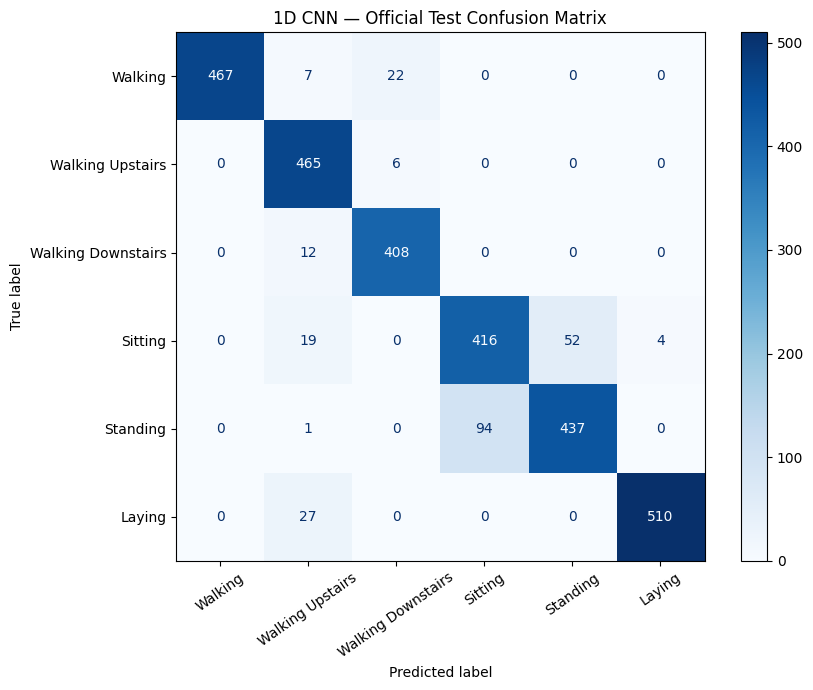

Saved figure: /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/cnn_confusion_matrix.png


In [10]:
# ------------------------------------------------------------
# CNN confusion matrix
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test_cnn,
    test_predictions_cnn,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=35,
    values_format="d",
    ax=ax
)

ax.set_title("1D CNN — Official Test Confusion Matrix")
plt.tight_layout()

cnn_cm_path = FIGURES_DIR / "cnn_confusion_matrix.png"
plt.savefig(cnn_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", cnn_cm_path)

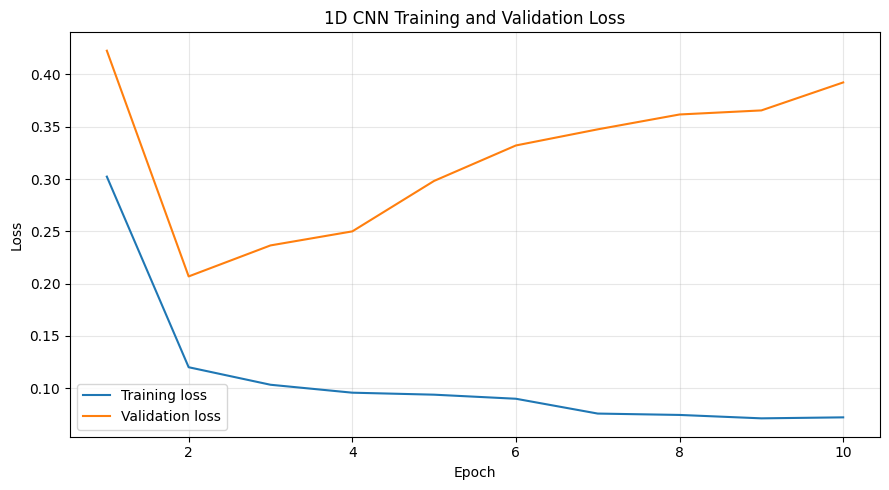

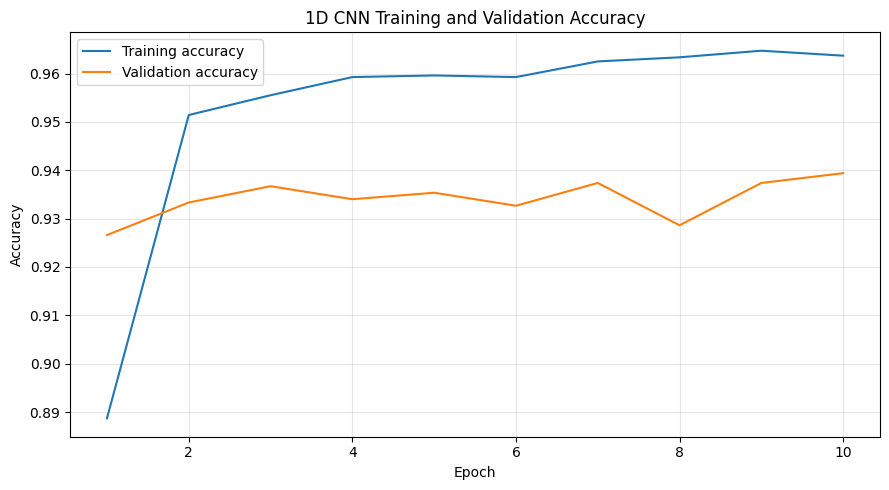

Saved:
- /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/cnn_training_validation_loss.png
- /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/cnn_training_validation_accuracy.png


In [11]:
# ------------------------------------------------------------
# Training curves
# ------------------------------------------------------------
epochs = range(1, len(history.history["loss"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, history.history["loss"], label="Training loss")
ax.plot(epochs, history.history["val_loss"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("1D CNN Training and Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

loss_path = FIGURES_DIR / "cnn_training_validation_loss.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, history.history["accuracy"], label="Training accuracy")
ax.plot(epochs, history.history["val_accuracy"], label="Validation accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("1D CNN Training and Validation Accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

accuracy_path = FIGURES_DIR / "cnn_training_validation_accuracy.png"
plt.savefig(accuracy_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print("-", loss_path)
print("-", accuracy_path)

,Model,Input,Test Accuracy,Macro F1,Key Observation
0,Random Forest (handcrafted features),561 engineered time/frequency-domain features,0.9257,0.9238,Best overall accuracy; benefits from handcraft...
1,1D CNN (raw sensor signals),Raw 9-channel sequences (128 time steps),0.9172,0.9182,Competitive using only raw sensor signals; wea...


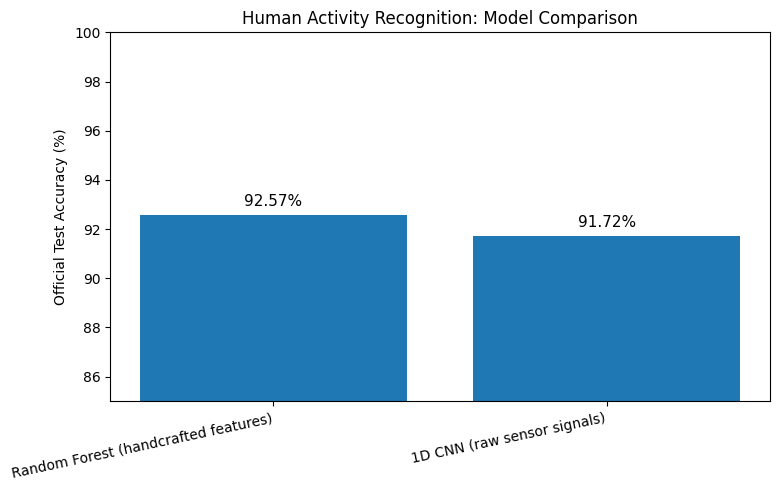

Saved comparison table to: /content/drive/MyDrive/HAR_1D_CNN_Project/results/tables/final_model_comparison.csv
Saved comparison figure to: /content/drive/MyDrive/HAR_1D_CNN_Project/results/figures/model_comparison.png


In [12]:
# ============================================================
# Final model comparison
# ============================================================

comparison_df = pd.DataFrame({
    "Model": [
        "Random Forest (handcrafted features)",
        "1D CNN (raw sensor signals)"
    ],
    "Input": [
        "561 engineered time/frequency-domain features",
        "Raw 9-channel sequences (128 time steps)"
    ],
    "Test Accuracy": [
        0.9257,
        0.9172
    ],
    "Macro F1": [
        0.9238,
        0.9182
    ],
    "Key Observation": [
        "Best overall accuracy; benefits from handcrafted domain features",
        "Competitive using only raw sensor signals; weaker on Sitting vs Standing"
    ]
})

display(comparison_df)

# Save table
comparison_df.to_csv(
    TABLES_DIR / "final_model_comparison.csv",
    index=False
)

# Accuracy comparison figure
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Test Accuracy"] * 100
)

plt.ylabel("Official Test Accuracy (%)")
plt.title("Human Activity Recognition: Model Comparison")
plt.ylim(85, 100)
plt.xticks(rotation=12, ha="right")

for bar, score in zip(bars, comparison_df["Test Accuracy"] * 100):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.35,
        f"{score:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

comparison_figure_path = FIGURES_DIR / "model_comparison.png"
plt.savefig(comparison_figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved comparison table to:", TABLES_DIR / "final_model_comparison.csv")
print("Saved comparison figure to:", comparison_figure_path)